# TRELLIS 1 — Fresh Colab Deployment (stable path)

This notebook is a clean Colab-first deployment path for **base TRELLIS inference**.

It is built around the failure modes from the earlier notebooks:
- avoid one huge `setup.sh --new-env ...` cell
- avoid Colab system Python / system Torch drift
- pin the environment to **Python 3.10 + PyTorch 2.4.0 + CUDA 11.8 wheels**
- compile native extensions against the **conda CUDA 11.8** toolchain, not `/usr/local/cuda`
- build `nvdiffrast`, `diffoctreerast`, and `diff-gaussian-rasterization` manually with `--no-build-isolation`
- use **`xformers`** as the attention backend

Run the notebook **top to bottom**.  
If you already have a broken partial install, run the optional cleanup cell first.


## 0) Check runtime

In Colab, first switch to **GPU runtime**:

**Runtime → Change runtime type → GPU**


In [1]:
import os, sys, subprocess

print("Python:", sys.version)
subprocess.run("nvidia-smi", shell=True, check=False)

if "COLAB_GPU" not in os.environ:
    raise RuntimeError("No Colab GPU runtime detected. Switch the runtime to GPU first.")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1) Install Linux build dependencies


In [2]:
%%bash
set -eo pipefail
apt-get update -y
apt-get install -y   build-essential cmake ninja-build git wget pkg-config   libgl1-mesa-dev libglib2.0-0


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,497 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,996 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,143 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2) Install Miniconda inside Colab


In [3]:
%%bash
set -eo pipefail

if [ ! -x /content/miniconda/bin/conda ]; then
  wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
  bash /tmp/miniconda.sh -b -p /content/miniconda
fi

eval "$(/content/miniconda/bin/conda shell.bash hook)"
conda --version


PREFIX=/content/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /content/miniconda
conda 26.1.1


## 3) Create the `trellis` environment

This cell also accepts Conda's default-channel Terms of Service when needed.


In [4]:
%%bash
set -eo pipefail

eval "$(/content/miniconda/bin/conda shell.bash hook)"

# Accept ToS if this conda build requires it.
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main >/dev/null 2>&1 || true
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r >/dev/null 2>&1 || true

if ! conda env list | awk '{print $1}' | grep -qx trellis; then
  conda create -n trellis -y python=3.10 pip setuptools wheel
fi

conda activate trellis
python -V
python -m pip --version


Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - \ | / - \ | / - done
Channels:
 - defaults
Platform: linux-64
Solving environment: \ done

## Package Plan ##

  environment location: /content/miniconda/envs/trellis

  added / updated specs:
    - pip
    - python=3.10
    - setuptools
    - wheel


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       h06a4308_0         126 KB
    ld_impl_linux-64-2.44      |       h9e0c5a2_3         725 KB
    libexpat-2.7.5             |       h7354ed3_0         122 KB
    libnsl-2.0.0               |       h5eee18b_0          31 KB
    packaging-26.0             |  py310h06a4308_0         165 KB
    pip-26.0.1                 |     pyhc872135_1         1.1 MB
    python-3.10.20             |       h741d88c_0        24.1 MB
    setuptools-82.0.1          |  p



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




## 4) Install the exact PyTorch stack TRELLIS expects

This forces the environment to the stable combination used by TRELLIS's default `--new-env` path:
- `torch==2.4.0`
- `torchvision==0.19.0`
- `torchaudio==2.4.0`
- CUDA 11.8 wheels


In [5]:
%%bash
set -eo pipefail

eval "$(/content/miniconda/bin/conda shell.bash hook)"
conda activate trellis

python -m pip uninstall -y torch torchvision torchaudio triton >/dev/null 2>&1 || true
conda remove -y mkl mkl-service intel-openmp >/dev/null 2>&1 || true

python -m pip install --upgrade pip setuptools wheel
python -m pip install --no-cache-dir --force-reinstall \
  torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 \
  --index-url https://download.pytorch.org/whl/cu118

python - <<'PY'
import torch
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
PY


Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.7/857.7 MB 75.4 MB/s  0:00:07
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 24.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 225.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 257.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 741.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 396.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 85.9 MB/s  0:00:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 314.1 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 377.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 298.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 221.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 326.9 

## 5) Clone TRELLIS


In [6]:
%%bash
set -eo pipefail

cd /content
if [ ! -d /content/TRELLIS/.git ]; then
  git clone --recurse-submodules https://github.com/microsoft/TRELLIS.git
else
  cd /content/TRELLIS
  git submodule update --init --recursive
fi


Submodule path 'trellis/representations/mesh/flexicubes': checked out '815e075a2a400d06c48d94c347674344ed6ae5c5'


Cloning into 'TRELLIS'...
Submodule 'trellis/representations/mesh/flexicubes' (https://github.com/MaxtirError/FlexiCubes.git) registered for path 'trellis/representations/mesh/flexicubes'
Cloning into '/content/TRELLIS/trellis/representations/mesh/flexicubes'...


## 6) Create a reusable environment helper

Later bash cells only need:

```bash
source /content/trellis_env.sh
```


In [7]:
%%bash
set -eo pipefail

cat > /content/trellis_env.sh <<'EOF'
eval "$(/content/miniconda/bin/conda shell.bash hook)"
conda activate trellis

export PYTHONPATH=/content/TRELLIS:${PYTHONPATH:-}
export ATTN_BACKEND=xformers
export SPCONV_ALGO=native

unset CUDA_HOME
export CUDA_HOME=$CONDA_PREFIX
export PATH=$CONDA_PREFIX/bin:$PATH
export LD_LIBRARY_PATH=$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LD_LIBRARY_PATH:-}
export CPATH=$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPATH:-}

if command -v x86_64-conda-linux-gnu-cc >/dev/null 2>&1; then
  export CC=$(which x86_64-conda-linux-gnu-cc)
fi
if command -v x86_64-conda-linux-gnu-c++ >/dev/null 2>&1; then
  export CXX=$(which x86_64-conda-linux-gnu-c++)
  export CUDAHOSTCXX=$CXX
fi

export TORCH_CUDA_ARCH_LIST=$(python - <<'PY'
import torch
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"{major}.{minor}")
else:
    print("7.5")
PY
)
EOF

cat /content/trellis_env.sh


eval "$(/content/miniconda/bin/conda shell.bash hook)"
conda activate trellis

export PYTHONPATH=/content/TRELLIS:${PYTHONPATH:-}
export ATTN_BACKEND=xformers
export SPCONV_ALGO=native

unset CUDA_HOME
export CUDA_HOME=$CONDA_PREFIX
export PATH=$CONDA_PREFIX/bin:$PATH
export LD_LIBRARY_PATH=$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LD_LIBRARY_PATH:-}
export CPATH=$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPATH:-}

if command -v x86_64-conda-linux-gnu-cc >/dev/null 2>&1; then
  export CC=$(which x86_64-conda-linux-gnu-cc)
fi
if command -v x86_64-conda-linux-gnu-c++ >/dev/null 2>&1; then
  export CXX=$(which x86_64-conda-linux-gnu-c++)
  export CUDAHOSTCXX=$CXX
fi

export TORCH_CUDA_ARCH_LIST=$(python - <<'PY'
import torch
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"{major}.{minor}")
else:
    print("7.5")
PY
)


## 7) Install TRELLIS basic Python dependencies

This mirrors the current `setup.sh --basic` dependency list, but keeps the notebook fully explicit.


In [8]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

python -m pip install \
  pillow imageio imageio-ffmpeg tqdm easydict opencv-python-headless scipy ninja \
  rembg onnxruntime trimesh open3d xatlas pyvista pymeshfix igraph transformers

python -m pip install \
  git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 136.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 56.3 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 107.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 121.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 44.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 31.4 MB/s  0:00:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 73.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 60.5 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 96.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 35.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 91.7 MB/s  0:00:00
   ━━━━━━

  Running command git clone --filter=blob:none --quiet https://github.com/EasternJournalist/utils3d.git /tmp/pip-req-build-wf_1xlg2
  Running command git rev-parse -q --verify 'sha^9a4eb15e4021b67b12c460c7057d642626897ec8'
  Running command git fetch -q https://github.com/EasternJournalist/utils3d.git 9a4eb15e4021b67b12c460c7057d642626897ec8
  Running command git checkout -q 9a4eb15e4021b67b12c460c7057d642626897ec8


## 8) Install `xformers`, `spconv`, and `kaolin`

These versions match TRELLIS's current setup mapping for **PyTorch 2.4.0**.


In [9]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

python -m pip install xformers==0.0.27.post2 --index-url https://download.pytorch.org/whl/cu118
python -m pip install spconv-cu118
python -m pip install kaolin -f https://nvidia-kaolin.s3.us-east-2.amazonaws.com/torch-2.4.0_cu121.html


Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 75.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 MB 37.1 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 62.9 MB/s  0:00:00

Looking in links: https://nvidia-kaolin.s3.us-east-2.amazonaws.com/torch-2.4.0_cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.1/854.1 kB 31.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 40.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 MB 68.3 MB/s  0:00:01



## 9) Install the CUDA 11.8 compiler + build toolchain inside the conda env

This is critical. The native extensions must compile against the same CUDA family as PyTorch (`cu118`).


In [10]:
%%bash
set -eo pipefail

eval "$(/content/miniconda/bin/conda shell.bash hook)"
conda activate trellis

conda install -y -c nvidia cuda-nvcc=11.8 cuda-cudart-dev=11.8 cuda-libraries-dev=11.8 || \
conda install -y -c nvidia cuda-nvcc=11.8 cuda-cudart-dev=11.8 libcusparse-dev

conda install -y -c conda-forge gcc_linux-64=11 gxx_linux-64=11 cmake ninja make

source /content/trellis_env.sh

echo "TORCH_CUDA_ARCH_LIST=$TORCH_CUDA_ARCH_LIST"
which nvcc
nvcc --version

python - <<'PY'
import torch
from torch.utils.cpp_extension import CUDA_HOME
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("CUDA_HOME:", CUDA_HOME)
PY


Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - nvidia
 - defaults
Platform: linux-64
Solving environment: \ done

## Package Plan ##

  environment location: /content/miniconda/envs/trellis

  added / updated specs:
    - cuda-cudart-dev=11.8
    - cuda-libraries-dev=11.8
    - cuda-nvcc=11.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cuda-cccl-13.2.27          |       hfa048b0_0          18 KB  nvidia
    cuda-cccl_linux-64-13.2.27 |                0         1.3 MB  nvidia
    cuda-crt-dev_linux-64-13.2.51|                0          85 KB  nvidia
    cuda-cudart-13.2.51        |       hb83dc92_0          19 KB  nvidia
    cuda-cudart-dev-11.8.89    |                0         1.1 MB  nvidia
    cuda-cudart-dev_linux-64-13.2.51|       h74be60c_0         383 KB  nvidia
    cuda-cudart-static_linux-64-13.2.51|       h74be60c_0         1.0 MB  nvidia
    cuda-c



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




## 10) Build `nvdiffrast` manually

`setup.sh` installs this with plain `pip install`, but the reliable path here is manual build + `--no-build-isolation`.


In [11]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

# Make sure both runtime + dev cudart are present
conda install -y -c nvidia cuda-cudart=11.8 cuda-cudart-dev=11.8 cuda-libraries-dev=11.8

# Make linker search both common conda CUDA locations
export LIBRARY_PATH="$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LIBRARY_PATH:-}"
export LDFLAGS="-L$CONDA_PREFIX/lib -L$CONDA_PREFIX/targets/x86_64-linux/lib ${LDFLAGS:-}"

# If libcudart only exists under targets/, expose it in $CONDA_PREFIX/lib too
if [ -f "$CONDA_PREFIX/targets/x86_64-linux/lib/libcudart.so" ] && [ ! -e "$CONDA_PREFIX/lib/libcudart.so" ]; then
  ln -s "$CONDA_PREFIX/targets/x86_64-linux/lib/libcudart.so" "$CONDA_PREFIX/lib/libcudart.so"
fi

if [ -f "$CONDA_PREFIX/targets/x86_64-linux/lib/libcudart.so.11.0" ] && [ ! -e "$CONDA_PREFIX/lib/libcudart.so.11.0" ]; then
  ln -s "$CONDA_PREFIX/targets/x86_64-linux/lib/libcudart.so.11.0" "$CONDA_PREFIX/lib/libcudart.so.11.0"
fi

echo "=== CUDA runtime check ==="
ls -l "$CONDA_PREFIX/lib"/libcudart.so* || true
ls -l "$CONDA_PREFIX/targets/x86_64-linux/lib"/libcudart.so* || true

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - nvidia
 - defaults
Platform: linux-64
Solving environment: \ | done

## Package Plan ##

  environment location: /content/miniconda/envs/trellis

  added / updated specs:
    - cuda-cudart-dev=11.8
    - cuda-cudart=11.8
    - cuda-libraries-dev=11.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cuda-cudart-11.8.89        |                0         197 KB  nvidia
    ------------------------------------------------------------
                                           Total:         197 KB

The following packages will be DOWNGRADED:

  cuda-cudart                            13.2.51-hb83dc92_0 --> 11.8.89-0 



 done
Preparing transaction: - done
Verifying transaction: | done
Executing transaction: - done
=== CUDA runtime check ===
lrwxrwxrwx 1 root root     20 Apr  9 17:37 /content/miniconda/envs/trellis/



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [12]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

export LIBRARY_PATH="$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LIBRARY_PATH:-}"
export LDFLAGS="-L$CONDA_PREFIX/lib -L$CONDA_PREFIX/targets/x86_64-linux/lib ${LDFLAGS:-}"

rm -rf /tmp/extensions/nvdiffrast
mkdir -p /tmp/extensions
git clone -b v0.4.0 https://github.com/NVlabs/nvdiffrast.git /tmp/extensions/nvdiffrast
cd /tmp/extensions/nvdiffrast

python setup.py clean --all || true
python setup.py build_ext --inplace -v
python -m pip install --no-build-isolation -e .

python - <<'PY'
import nvdiffrast.torch as dr
print("nvdiffrast OK")
PY

running clean
running build_ext
building '_nvdiffrast_c' extension
creating /tmp/extensions/nvdiffrast/build/temp.linux-x86_64-cpython-310/csrc/common
creating /tmp/extensions/nvdiffrast/build/temp.linux-x86_64-cpython-310/csrc/common/cudaraster/impl
creating /tmp/extensions/nvdiffrast/build/temp.linux-x86_64-cpython-310/csrc/torch
[1/15] /content/miniconda/envs/trellis/bin/x86_64-conda-linux-gnu-c++ -MMD -MF /tmp/extensions/nvdiffrast/build/temp.linux-x86_64-cpython-310/csrc/common/common.o.d -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /content/miniconda/envs/trellis/include -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /content/miniconda/envs/trellis/include -fPIC -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include/torch/csrc/api/include -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/in

Cloning into '/tmp/extensions/nvdiffrast'...
Note: switching to '253ac4fcea7de5f396371124af597e6cc957bfae'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

'build/lib.linux-x86_64-cpython-310' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.10' does not exist -- can't clean it
/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/utils/cpp_extension.py:424: UserWarning: There are no /content/miniconda/envs/trellis/bin/x86_64-conda-linux-gnu-c++ version

## 11) Build `diffoctreerast` manually


In [13]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

# Try to make sure CUDA CUB/Thrust headers are present
conda install -y -c nvidia cuda-cccl=11.8 || conda install -y -c nvidia cuda-cccl || true

# If CUB exists under targets/, expose it in $CONDA_PREFIX/include too
if [ -d "$CONDA_PREFIX/targets/x86_64-linux/include/cub" ] && [ ! -e "$CONDA_PREFIX/include/cub" ]; then
  ln -s "$CONDA_PREFIX/targets/x86_64-linux/include/cub" "$CONDA_PREFIX/include/cub"
fi

if [ -d "$CONDA_PREFIX/targets/x86_64-linux/include/thrust" ] && [ ! -e "$CONDA_PREFIX/include/thrust" ]; then
  ln -s "$CONDA_PREFIX/targets/x86_64-linux/include/thrust" "$CONDA_PREFIX/include/thrust"
fi

export CPATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPATH:-}"
export CPLUS_INCLUDE_PATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPLUS_INCLUDE_PATH:-}"

echo "=== checking CUB ==="
find "$CONDA_PREFIX" -path "*/cub/cub.cuh" | head -n 10 || true
ls -ld "$CONDA_PREFIX/include/cub" || true
ls -ld "$CONDA_PREFIX/include/thrust" || true

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - nvidia
 - defaults
Platform: linux-64
Solving environment: | / done

## Package Plan ##

  environment location: /content/miniconda/envs/trellis

  added / updated specs:
    - cuda-cccl=11.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cuda-cccl-11.8.89          |                0         1.2 MB  nvidia
    ------------------------------------------------------------
                                           Total:         1.2 MB

The following packages will be DOWNGRADED:

  cuda-cccl                              13.2.27-hfa048b0_0 --> 11.8.89-0 



 done
Preparing transaction: \ done
Verifying transaction: / - done
Executing transaction: | done
=== checking CUB ===
/content/miniconda/envs/trellis/targets/x86_64-linux/include/cccl/cub/cub.cuh
/content/miniconda/envs/trellis/include/cub/cub.cuh
drwxr-



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [14]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

export CPATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPATH:-}"
export CPLUS_INCLUDE_PATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPLUS_INCLUDE_PATH:-}"
export LIBRARY_PATH="$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LIBRARY_PATH:-}"
export LDFLAGS="-L$CONDA_PREFIX/lib -L$CONDA_PREFIX/targets/x86_64-linux/lib ${LDFLAGS:-}"

rm -rf /tmp/extensions/diffoctreerast
mkdir -p /tmp/extensions
git clone --recurse-submodules https://github.com/JeffreyXiang/diffoctreerast.git /tmp/extensions/diffoctreerast
cd /tmp/extensions/diffoctreerast

python setup.py clean --all || true
python setup.py build_ext --inplace -v
python -m pip install --no-build-isolation -e .

python - <<'PY'
import diffoctreerast
print("diffoctreerast OK")
PY

Submodule path 'lib/glm': checked out '33b4a621a697a305bc3a7610d290677b96beb181'
running clean
running build_ext
building 'diffoctreerast._C' extension
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_decoupoly_rasterizer
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_decoupoly_rasterizer/cuda
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_gaussian_rasterizer
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_gaussian_rasterizer/cuda
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_trivec_rasterizer
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_trivec_rasterizer/cuda
creating /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/src/octree_voxel_rasterizer
creating 

Cloning into '/tmp/extensions/diffoctreerast'...
Submodule 'lib/glm' (https://github.com/g-truc/glm.git) registered for path 'lib/glm'
Cloning into '/tmp/extensions/diffoctreerast/lib/glm'...
'build/lib.linux-x86_64-cpython-310' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.10' does not exist -- can't clean it
/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/utils/cpp_extension.py:424: UserWarning: There are no /content/miniconda/envs/trellis/bin/x86_64-conda-linux-gnu-c++ version bounds defined for CUDA version 11.8
  warnings.warn(f'There are no {compiler_name} version bounds defined for CUDA version {cuda_str_version}')
Emitting ninja build file /tmp/extensions/diffoctreerast/build/temp.linux-x86_64-cpython-310/build.ninja...
Compiling objects...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


## 12) Build the Gaussian rasterizer from `mip-splatting` manually


In [15]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

export CPATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPATH:-}"
export CPLUS_INCLUDE_PATH="$CONDA_PREFIX/include:$CONDA_PREFIX/targets/x86_64-linux/include:${CPLUS_INCLUDE_PATH:-}"
export LIBRARY_PATH="$CONDA_PREFIX/lib:$CONDA_PREFIX/targets/x86_64-linux/lib:${LIBRARY_PATH:-}"
export LDFLAGS="-L$CONDA_PREFIX/lib -L$CONDA_PREFIX/targets/x86_64-linux/lib ${LDFLAGS:-}"

rm -rf /tmp/extensions/mip-splatting
mkdir -p /tmp/extensions
git clone https://github.com/autonomousvision/mip-splatting.git /tmp/extensions/mip-splatting
cd /tmp/extensions/mip-splatting/submodules/diff-gaussian-rasterization

python setup.py clean --all || true
python setup.py build_ext --inplace -v
python -m pip install --no-build-isolation -e .

python - <<'PY'
import diff_gaussian_rasterization
print("diff_gaussian_rasterization OK")
PY


running clean
running build_ext
building 'diff_gaussian_rasterization._C' extension
creating /tmp/extensions/mip-splatting/submodules/diff-gaussian-rasterization/build/temp.linux-x86_64-cpython-310/cuda_rasterizer
[1/5] /content/miniconda/envs/trellis/bin/nvcc --generate-dependencies-with-compile --dependency-output /tmp/extensions/mip-splatting/submodules/diff-gaussian-rasterization/build/temp.linux-x86_64-cpython-310/cuda_rasterizer/forward.o.d -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include/torch/csrc/api/include -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include/TH -I/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/include/THC -I/content/miniconda/envs/trellis/include -I/content/miniconda/envs/trellis/include/python3.10 -c -c /tmp/extensions/mip-splatting/submodules/diff-gaussian-rasterization/cuda_rasterizer/forward.cu -o /tmp/extens

Cloning into '/tmp/extensions/mip-splatting'...
'build/lib.linux-x86_64-cpython-310' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.10' does not exist -- can't clean it
/content/miniconda/envs/trellis/lib/python3.10/site-packages/torch/utils/cpp_extension.py:424: UserWarning: There are no /content/miniconda/envs/trellis/bin/x86_64-conda-linux-gnu-c++ version bounds defined for CUDA version 11.8
  warnings.warn(f'There are no {compiler_name} version bounds defined for CUDA version {cuda_str_version}')
Emitting ninja build file /tmp/extensions/mip-splatting/submodules/diff-gaussian-rasterization/build/temp.linux-x86_64-cpython-310/build.ninja...
Compiling objects...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


## 13) Final verification


In [16]:
%%bash
set -eo pipefail
source /content/trellis_env.sh
cd /content/TRELLIS

python - <<'PY'
import importlib, os, torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("ATTN_BACKEND:", os.environ.get("ATTN_BACKEND"))
print("SPCONV_ALGO:", os.environ.get("SPCONV_ALGO"))

mods = [
    "trellis",
    "xformers",
    "spconv",
    "kaolin",
    "nvdiffrast.torch",
    "diff_gaussian_rasterization",
]
for m in mods:
    try:
        importlib.import_module(m)
        print("[OK]", m)
    except Exception as e:
        print("[FAIL]", m, e)

from trellis.pipelines import TrellisImageTo3DPipeline
print("[OK] TrellisImageTo3DPipeline")
PY


torch: 2.4.0+cu118
torch cuda: 11.8
cuda available: True
gpu: Tesla T4
ATTN_BACKEND: xformers
SPCONV_ALGO: native
[SPARSE] Backend: spconv, Attention: xformers
[OK] trellis
[OK] xformers
[OK] spconv
[OK] kaolin
[OK] nvdiffrast.torch
[OK] diff_gaussian_rasterization
[OK] TrellisImageTo3DPipeline


## 14) Smoke test with TRELLIS's example image

This downloads the pretrained weights from Hugging Face and generates:
- `.glb`
- `.ply`
- preview `.mp4` files

This cell can take a while on the first run.


In [17]:
%%bash
set -eo pipefail
source /content/trellis_env.sh
cd /content/TRELLIS
mkdir -p /content/trellis_outputs_smoke

python - <<'PY'
import imageio
from PIL import Image
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import render_utils, postprocessing_utils

pipeline = TrellisImageTo3DPipeline.from_pretrained("microsoft/TRELLIS-image-large")
pipeline.cuda()

image = Image.open("/content/TRELLIS/assets/example_image/T.png").convert("RGBA")
outputs = pipeline.run(image, seed=1)

video = render_utils.render_video(outputs["gaussian"][0])["color"]
imageio.mimsave("/content/trellis_outputs_smoke/output_gs.mp4", video, fps=30)

video = render_utils.render_video(outputs["radiance_field"][0])["color"]
imageio.mimsave("/content/trellis_outputs_smoke/output_rf.mp4", video, fps=30)

video = render_utils.render_video(outputs["mesh"][0])["normal"]
imageio.mimsave("/content/trellis_outputs_smoke/output_mesh.mp4", video, fps=30)

glb = postprocessing_utils.to_glb(
    outputs["gaussian"][0],
    outputs["mesh"][0],
    simplify=0.95,
    texture_size=1024,
)
glb.export("/content/trellis_outputs_smoke/output.glb")

outputs["gaussian"][0].save_ply("/content/trellis_outputs_smoke/output.ply")

print("Smoke test complete.")
PY


[SPARSE] Backend: spconv, Attention: xformers
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
Before postprocess: 296544 vertices, 593540 faces
After decimate: 14557 vertices, 29677 faces

Loading ..98%

100% done Found 527 invisible faces
Dual graph: 44248 edges
Mincut solved, start checking the cut
Removed 1332 faces by mincut
After remove invisible faces: 14076 vertices, 28442 faces
Smoke test complete.



/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/content/mi

## 15) Show smoke-test outputs


In [18]:
%%bash
set -eo pipefail
find /content/trellis_outputs_smoke -maxdepth 1 -type f | sort


/content/trellis_outputs_smoke/output.glb
/content/trellis_outputs_smoke/output_gs.mp4
/content/trellis_outputs_smoke/output_mesh.mp4
/content/trellis_outputs_smoke/output.ply
/content/trellis_outputs_smoke/output_rf.mp4


## 16) Upload your own image (optional)

Use a single PNG/JPG input image.


In [ ]:
from pathlib import Path

try:
    from google.colab import files
except Exception:
    raise RuntimeError("This upload helper is meant for Google Colab.")

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No file uploaded.")

name = next(iter(uploaded))
target = Path("/content/user_image.png")
target.write_bytes(uploaded[name])
print("Saved uploaded file to", target)


## 17) Run TRELLIS on your uploaded image


In [ ]:
%%bash
set -eo pipefail
test -f /content/user_image.png
source /content/trellis_env.sh
cd /content/TRELLIS
mkdir -p /content/trellis_outputs_user

python - <<'PY'
import imageio
from PIL import Image
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import render_utils, postprocessing_utils

img_path = "/content/user_image.png"

pipeline = TrellisImageTo3DPipeline.from_pretrained("microsoft/TRELLIS-image-large")
pipeline.cuda()

image = Image.open(img_path).convert("RGBA")
outputs = pipeline.run(image, seed=1)

video = render_utils.render_video(outputs["gaussian"][0])["color"]
imageio.mimsave("/content/trellis_outputs_user/output_gs.mp4", video, fps=30)

video = render_utils.render_video(outputs["radiance_field"][0])["color"]
imageio.mimsave("/content/trellis_outputs_user/output_rf.mp4", video, fps=30)

video = render_utils.render_video(outputs["mesh"][0])["normal"]
imageio.mimsave("/content/trellis_outputs_user/output_mesh.mp4", video, fps=30)

glb = postprocessing_utils.to_glb(
    outputs["gaussian"][0],
    outputs["mesh"][0],
    simplify=0.95,
    texture_size=1024,
)
glb.export("/content/trellis_outputs_user/output.glb")

outputs["gaussian"][0].save_ply("/content/trellis_outputs_user/output.ply")

print("Done.")
PY


## 18) Zip the user outputs


In [ ]:
%%bash
set -eo pipefail
cd /content
rm -f trellis_outputs_user.zip
if [ -d /content/trellis_outputs_user ]; then
  zip -r /content/trellis_outputs_user.zip /content/trellis_outputs_user >/dev/null
fi
find /content/trellis_outputs_user -maxdepth 1 -type f | sort || true
ls -lh /content/trellis_outputs_user.zip || true


## What this notebook changed compared with the earlier failed attempts

1. It does **not** rely on Colab's preinstalled Python / Torch stack.
2. It does **not** use one giant `setup.sh --new-env ...` cell.
3. It pins the Torch/CUDA pair first, then compiles extensions against the matching **conda CUDA 11.8** toolkit.
4. It builds the three fragile native extensions manually with `--no-build-isolation`.
5. It uses `xformers` instead of `flash-attn` for better Colab compatibility.


# EDITNET TRAINING / RETRAINING SECTION



Everything below is only the **EditNet training and retraining workflow**. In this section, I:
- overlay my EditNet training files on top of the working TRELLIS deployment
- create the helper loss file required by the training scripts
- create the working directories and `/workspace` mapping expected by my code
- verify the source images available for training
- encode source images into **cached latents**
- build `training_pairs.json`
- run a small smoke-test training job
- scale to medium and large runs depending on the GPU



## A) Overlay my EditNet training repository on top of the deployed TRELLIS checkout

In this cell I clone my review repository and copy the **training-specific files** into the already working TRELLIS deployment.  
This is where I bring in:
- `train_edit_delta_scalable.py`
- `train_edit_delta_cached.py`
- `run_edit_train.sh`
- `eval_rerun_checkpoint.py`
- `trellis/models/edit_net.py`



In [19]:
%%bash
set -eo pipefail

cd /content
rm -rf editnet_repo

git clone --single-branch \
  https://github.com/SamOrTrinity/trellis-editnet-review-repo.git \
  /content/editnet_repo

cp /content/editnet_repo/train_edit_delta_cached.py /content/TRELLIS/
cp /content/editnet_repo/train_edit_delta_scalable.py /content/TRELLIS/
cp /content/editnet_repo/run_edit_train.sh /content/TRELLIS/
cp /content/editnet_repo/eval_rerun_checkpoint.py /content/TRELLIS/

mkdir -p /content/TRELLIS/trellis/models
cp /content/editnet_repo/trellis/models/edit_net.py /content/TRELLIS/trellis/models/

echo "Overlay complete."
ls -l /content/TRELLIS/train_edit_delta_scalable.py
ls -l /content/TRELLIS/trellis/models/edit_net.py
ls -l /content/TRELLIS/eval_rerun_checkpoint.py

Overlay complete.
-rw-r--r-- 1 root root 15352 Apr  9 18:08 /content/TRELLIS/train_edit_delta_scalable.py
-rw-r--r-- 1 root root 17949 Apr  9 18:08 /content/TRELLIS/trellis/models/edit_net.py
-rw-r--r-- 1 root root 3992 Apr  9 18:08 /content/TRELLIS/eval_rerun_checkpoint.py


Cloning into '/content/editnet_repo'...


## B) Create the helper loss file required by the training scripts

In my training flow, the scalable trainer imports `trellis.utils.edit_losses`.  
This helper file was required in the working setup, so in this cell I create it explicitly inside the TRELLIS tree.

This gives me:
- `clip_prompt_loss`
- `preservation_loss`
- `delta_regularisation_loss`
- `total_loss`

In [20]:
%%bash
set -eo pipefail

mkdir -p /content/TRELLIS/trellis/utils

cat > /content/TRELLIS/trellis/utils/edit_losses.py <<'PY'
import torch
import torch.nn.functional as F

def clip_prompt_loss(rendered_views_B, text_embedding, clip_model, clip_preprocess=None):
    """
    L_prompt: negative CLIP similarity between rendered edited views and text.
    """
    similarities = []

    for view in rendered_views_B:
        if view.shape[-1] != 224 or view.shape[-2] != 224:
            view = F.interpolate(view, size=(224, 224), mode="bilinear", align_corners=False)

        mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=view.device)
        std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=view.device)
        view = (view - mean[None, :, None, None]) / std[None, :, None, None]

        img_embedding = clip_model.encode_image(view)
        img_embedding = img_embedding / img_embedding.norm(dim=-1, keepdim=True)

        text_norm = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
        sim = (img_embedding * text_norm).sum(dim=-1)
        similarities.append(sim)

    mean_sim = torch.stack(similarities).mean(dim=0)
    return -mean_sim.mean()


def preservation_loss(depth_A_list, depth_B_list, normal_A_list, normal_B_list, mask_A_list):
    """
    L_preserve: depth/normal preservation inside silhouette.
    """
    depth_loss = 0.0
    normal_loss = 0.0
    n_views = len(depth_A_list)

    for i in range(n_views):
        m = mask_A_list[i]
        d_diff = (depth_A_list[i] - depth_B_list[i]).abs() * m
        depth_loss = depth_loss + d_diff.sum() / (m.sum() + 1e-8)

        n_diff = (normal_A_list[i] - normal_B_list[i]).abs() * m
        normal_loss = normal_loss + n_diff.sum() / (m.sum() * 3 + 1e-8)

    depth_loss = depth_loss / n_views
    normal_loss = normal_loss / n_views
    return depth_loss + normal_loss


def delta_regularisation_loss(delta):
    """
    L_delta: keep the predicted edit small.
    """
    return (delta ** 2).mean()


def total_loss(l_prompt, l_preserve, l_delta,
               lambda_prompt=1.0, lambda_preserve=0.5, lambda_delta=0.1):
    return (
        lambda_prompt * l_prompt
        + lambda_preserve * l_preserve
        + lambda_delta * l_delta
    )
PY

echo "Created /content/TRELLIS/trellis/utils/edit_losses.py"
ls -l /content/TRELLIS/trellis/utils/edit_losses.py

Created /content/TRELLIS/trellis/utils/edit_losses.py
-rw-r--r-- 1 root root 2138 Apr  9 18:08 /content/TRELLIS/trellis/utils/edit_losses.py


In [21]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

cd /content/TRELLIS

python - <<'PY'
from trellis.utils.edit_losses import delta_regularisation_loss
print("Import OK:", delta_regularisation_loss)
PY

[SPARSE] Backend: spconv, Attention: xformers
Import OK: <function delta_regularisation_loss at 0x7e60d3795000>


## C) Create the working directories and map `/workspace` to Colab

My training scripts are written around `/workspace/...` paths, but in Colab the files live under `/content/...`.  
In this cell I create the required directories and map them so the repo code can run without path edits.

This is also where I create:
- `/workspace/edit_training_data/encoded_latents`
- `/workspace/edit_training_data/training_pairs.json`
- `/workspace/edit_checkpoints`

In [22]:
%%bash
set -eo pipefail

mkdir -p /content/TRELLIS/assets/example_image
mkdir -p /content/edit_training_data/encoded_latents
mkdir -p /content/edit_checkpoints
mkdir -p /content/TRELLIS/artifacts
mkdir -p /workspace

ln -sfn /content/TRELLIS /workspace/TRELLIS
ln -sfn /content/edit_training_data /workspace/edit_training_data
ln -sfn /content/edit_checkpoints /workspace/edit_checkpoints

echo "Folders and workspace mapping ready."
ls -ld /workspace/TRELLIS
ls -ld /workspace/edit_training_data
ls -ld /workspace/edit_checkpoints

Folders and workspace mapping ready.
lrwxrwxrwx 1 root root 16 Apr  9 18:09 /workspace/TRELLIS -> /content/TRELLIS
lrwxrwxrwx 1 root root 27 Apr  9 18:09 /workspace/edit_training_data -> /content/edit_training_data
lrwxrwxrwx 1 root root 25 Apr  9 18:09 /workspace/edit_checkpoints -> /content/edit_checkpoints


## D) Install the OpenCLIP package used by the training loop

The EditNet training script loads frozen OpenCLIP to compute the prompt-alignment loss.  
In this cell I install `open-clip-torch` into the TRELLIS conda environment and verify the import.

In [23]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

/content/miniconda/envs/trellis/bin/python -m pip install -q open-clip-torch

/content/miniconda/envs/trellis/bin/python - <<'PY'
import open_clip
print("open_clip import OK")
PY

open_clip import OK


## E) Download the official TRELLIS pretrained model snapshot if it is not already present

My training scripts depend on the official TRELLIS backbone model weights.  
In this cell I download the `microsoft/TRELLIS-image-large` snapshot into a local model directory and expose it through `/workspace/hf_models`.

If the model is already cached, Hugging Face will reuse the cached files.

In [24]:
from huggingface_hub import snapshot_download
from pathlib import Path
import os

Path("/content/hf_models").mkdir(parents=True, exist_ok=True)
os.makedirs("/workspace", exist_ok=True)

# keep a workspace-compatible path too
if not os.path.exists("/workspace/hf_models"):
    os.symlink("/content/hf_models", "/workspace/hf_models")

snapshot_download(
    repo_id="microsoft/TRELLIS-image-large",
    local_dir="/content/hf_models/TRELLIS-image-large",
    local_dir_use_symlinks=False,
    resume_download=True,
)

print("Downloaded to /content/hf_models/TRELLIS-image-large")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Downloaded to /content/hf_models/TRELLIS-image-large


## F) Syntax-check the training stack before I start training

In this cell I verify that the key training files are syntactically valid:
- the scalable trainer
- my EditNet definition
- the loss helper file

This is a simple but useful check before launching any long run.

In [25]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

/content/miniconda/envs/trellis/bin/python -m py_compile /content/TRELLIS/train_edit_delta_scalable.py
/content/miniconda/envs/trellis/bin/python -m py_compile /content/TRELLIS/trellis/models/edit_net.py
/content/miniconda/envs/trellis/bin/python -m py_compile /content/TRELLIS/trellis/utils/edit_losses.py

echo "Syntax OK"

Syntax OK


## G) Check which source images are currently available for training

The source images used by my EditNet workflow live in:

`/workspace/TRELLIS/assets/example_image/`

In this cell I list the images currently available.  
These images are the inputs that I later encode into **cached latents**.

In [26]:
from pathlib import Path

img_dir = Path("/workspace/TRELLIS/assets/example_image")
imgs = sorted(list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg")))
print("Images found:", [p.name for p in imgs])
print("Total images found:", len(imgs))

Images found: ['T.png', 'typical_building_building.png', 'typical_building_castle.png', 'typical_building_colorful_cottage.png', 'typical_building_maya_pyramid.png', 'typical_building_mushroom.png', 'typical_building_space_station.png', 'typical_creature_dragon.png', 'typical_creature_elephant.png', 'typical_creature_furry.png', 'typical_creature_quadruped.png', 'typical_creature_robot_crab.png', 'typical_creature_robot_dinosour.png', 'typical_creature_rock_monster.png', 'typical_humanoid_block_robot.png', 'typical_humanoid_dragonborn.png', 'typical_humanoid_dwarf.png', 'typical_humanoid_goblin.png', 'typical_humanoid_mech.png', 'typical_misc_crate.png', 'typical_misc_fireplace.png', 'typical_misc_gate.png', 'typical_misc_lantern.png', 'typical_misc_magicbook.png', 'typical_misc_mailbox.png', 'typical_misc_monster_chest.png', 'typical_misc_paper_machine.png', 'typical_misc_phonograph.png', 'typical_misc_portal2.png', 'typical_misc_storage_chest.png', 'typical_misc_telephone.png', 'typi

## H) Encode source images into cached latents

This is the cell where I create the **cached latent dataset**.

For each source image, I:
1. preprocess the image with TRELLIS
2. compute the conditioning object `cond`
3. sample the sparse structure
4. sample the SLAT latent
5. save a `.pt` payload containing:
   - `image_name`
   - `cond`
   - `slat`

The output latents are written to:

`/workspace/edit_training_data/encoded_latents/`

This is the key dataset creation step for my EditNet training workflow.

In [27]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

/content/miniconda/envs/trellis/bin/python - <<'PY'
from pathlib import Path
from PIL import Image
import torch, gc

from trellis.pipelines import TrellisImageTo3DPipeline

IMAGE_DIR = Path("/workspace/TRELLIS/assets/example_image")
OUT_DIR = Path("/workspace/edit_training_data/encoded_latents")
MODEL_ID = "microsoft/TRELLIS-image-large"
MAX_IMAGES = 20   # change to 50 or 100 on a stronger runtime

OUT_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted(
    list(IMAGE_DIR.glob("*.png")) +
    list(IMAGE_DIR.glob("*.jpg")) +
    list(IMAGE_DIR.glob("*.jpeg"))
)[:MAX_IMAGES]

print("Found images:", len(image_files))
print([p.name for p in image_files])

pipeline = TrellisImageTo3DPipeline.from_pretrained(MODEL_ID)
pipeline.cuda()

for idx, img_path in enumerate(image_files, 1):
    out_path = OUT_DIR / f"{img_path.stem}.pt"
    if out_path.exists():
        print(f"[{idx}/{len(image_files)}] SKIP {img_path.name} (already encoded)")
        continue

    print(f"[{idx}/{len(image_files)}] Encoding {img_path.name}")
    img = Image.open(str(img_path))
    img = pipeline.preprocess_image(img)

    with torch.no_grad():
        cond = pipeline.get_cond([img])
        coords = pipeline.sample_sparse_structure(cond, 1)
        slat = pipeline.sample_slat(cond, coords)

    cond_cpu = {}
    for k, v in cond.items():
        if torch.is_tensor(v):
            cond_cpu[k] = v.detach().cpu()
        else:
            cond_cpu[k] = v

    try:
        slat_cpu = slat.cpu()
    except Exception:
        slat_cpu = slat

    payload = {
        "image_name": img_path.name,
        "cond": cond_cpu,
        "slat": slat_cpu,
    }
    torch.save(payload, out_path)
    print(f"    saved -> {out_path.name}")

    torch.cuda.empty_cache()
    gc.collect()

print("\nDone.")
print("Cached latents now:")
for p in sorted(OUT_DIR.glob("*.pt")):
    print(" -", p.name)
PY

[SPARSE] Backend: spconv, Attention: xformers
Found images: 20
['T.png', 'typical_building_building.png', 'typical_building_castle.png', 'typical_building_colorful_cottage.png', 'typical_building_maya_pyramid.png', 'typical_building_mushroom.png', 'typical_building_space_station.png', 'typical_creature_dragon.png', 'typical_creature_elephant.png', 'typical_creature_furry.png', 'typical_creature_quadruped.png', 'typical_creature_robot_crab.png', 'typical_creature_robot_dinosour.png', 'typical_creature_rock_monster.png', 'typical_humanoid_block_robot.png', 'typical_humanoid_dragonborn.png', 'typical_humanoid_dwarf.png', 'typical_humanoid_goblin.png', 'typical_humanoid_mech.png', 'typical_misc_crate.png']
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
[1/20] Encoding T.png
    saved -> T.pt
[2/20] Encoding typical_building_building.png
    saved -> typical_building_building.pt
[3/20] Encoding typical_building_castle.png
    saved -> typical_building_castle.pt
[4/20

/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/content/mi

## I) Verify the cached latent dataset that I just created

In this cell I list the `.pt` files that were written to the cached-latent folder.  
This is my quick verification that the encoded dataset creation step succeeded.

In [28]:
from pathlib import Path

cache_dir = Path("/workspace/edit_training_data/encoded_latents")
cache_files = sorted(cache_dir.glob("*.pt"))
print("Cached latents:", [p.name for p in cache_files])
print("Total cached latents:", len(cache_files))

Cached latents: ['T.pt', 'typical_building_building.pt', 'typical_building_castle.pt', 'typical_building_colorful_cottage.pt', 'typical_building_maya_pyramid.pt', 'typical_building_mushroom.pt', 'typical_building_space_station.pt', 'typical_creature_dragon.pt', 'typical_creature_elephant.pt', 'typical_creature_furry.pt', 'typical_creature_quadruped.pt', 'typical_creature_robot_crab.pt', 'typical_creature_robot_dinosour.pt', 'typical_creature_rock_monster.pt', 'typical_humanoid_block_robot.pt', 'typical_humanoid_dragonborn.pt', 'typical_humanoid_dwarf.pt', 'typical_humanoid_goblin.pt', 'typical_humanoid_mech.pt', 'typical_misc_crate.pt']
Total cached latents: 20


## J) Build `training_pairs.json` from the cached latents

In this cell I create the actual pair manifest used by the scalable trainer.

I use the prompt bank already defined in `trellis/models/edit_net.py`.  
For each cached object, I sample a configurable number of edit prompts and write the final pair list to:

`/workspace/edit_training_data/training_pairs.json`

This is the file that tells the trainer which cached object is paired with which edit prompt.

In [29]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

/content/miniconda/envs/trellis/bin/python - <<'PY'
from pathlib import Path
import json, random
from trellis.models.edit_net import EDIT_PROMPTS

CACHE_DIR = Path("/workspace/edit_training_data/encoded_latents")
OUT_JSON = Path("/workspace/edit_training_data/training_pairs.json")

MAX_OBJECTS = 20          # change to 50 or 100 later
PROMPTS_PER_IMAGE = 3     # 1 = light, 3 = medium, 5+ = heavy
SEED = 42

random.seed(SEED)

cache_files = sorted(CACHE_DIR.glob("*.pt"))[:MAX_OBJECTS]
uids = [p.stem for p in cache_files]

pairs = []
for uid in uids:
    chosen = random.sample(EDIT_PROMPTS, min(PROMPTS_PER_IMAGE, len(EDIT_PROMPTS)))
    for prompt in chosen:
        pairs.append({
            "uid": uid,
            "edit_prompt": prompt
        })

with open(OUT_JSON, "w") as f:
    json.dump(pairs, f, indent=2)

print("Objects used:", len(uids))
print("Pairs written:", len(pairs))
print("Saved to:", OUT_JSON)
print("\nPreview:")
print(json.dumps(pairs[:10], indent=2))
PY

[SPARSE] Backend: spconv, Attention: xformers
Objects used: 20
Pairs written: 60
Saved to: /workspace/edit_training_data/training_pairs.json

Preview:
[
  {
    "uid": "T",
    "edit_prompt": "make it shiny"
  },
  {
    "uid": "T",
    "edit_prompt": "paint it orange"
  },
  {
    "uid": "T",
    "edit_prompt": "make it blue"
  },
  {
    "uid": "typical_building_building",
    "edit_prompt": "make it rusty"
  },
  {
    "uid": "typical_building_building",
    "edit_prompt": "make it stone"
  },
  {
    "uid": "typical_building_building",
    "edit_prompt": "make it glass"
  },
  {
    "uid": "typical_building_castle",
    "edit_prompt": "make it silver"
  },
  {
    "uid": "typical_building_castle",
    "edit_prompt": "paint it purple"
  },
  {
    "uid": "typical_building_castle",
    "edit_prompt": "make it on fire"
  },
  {
    "uid": "typical_building_colorful_cottage",
    "edit_prompt": "make it black"
  }
]


## K) Run a small smoke-test EditNet training job

In this cell I run the **smallest practical training configuration** that I use to confirm the training pipeline is alive.

This run uses:
- very few objects
- very few prompts
- one rendered view
- low render resolution
- a strict voxel cap

I use this cell first to confirm that training, loss logging, and checkpoint saving are all working before I scale up.

In [30]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

cd /workspace/TRELLIS
unset HF_HUB_OFFLINE

export EDIT_EPOCHS=2
export EDIT_MAX_OBJECTS=1
export EDIT_PROMPTS_PER_OBJECT=1
export EDIT_N_VIEWS=1
export EDIT_RENDER_RES=128
export EDIT_TEXT_GAIN=4.0
export EDIT_TEXT_REPEAT=8
export EDIT_SCALE=0.15
export EDIT_LAMBDA_DELTA=0.02
export EDIT_LAMBDA_PRESERVE=0.05
export EDIT_MAX_VOXELS=20000
export EDIT_CACHE_DIR=/workspace/edit_training_data/encoded_latents
export EDIT_PAIRS_JSON=/workspace/edit_training_data/training_pairs.json
export EDIT_CKPT_DIR=/workspace/edit_checkpoints
export EDIT_LOG=/workspace/TRELLIS/artifacts/smoke_run.log

/content/miniconda/envs/trellis/bin/python -u /workspace/TRELLIS/train_edit_delta_scalable.py 2>&1 | tee "$EDIT_LOG"

[SPARSE] Backend: spconv, Attention: xformers
  Architecture 2: Delta Training (FINAL)

[1/4] Loading TRELLIS 1 and cached latents...
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:51: FutureWar

## L) Inspect the smoke-test run

In this cell I inspect:
- the tail of the smoke-test log
- the checkpoints written by the trainer

This is my quick post-run verification step.

In [31]:
%%bash
echo "===== LOG TAIL ====="
tail -n 120 /workspace/TRELLIS/artifacts/smoke_run.log || true

echo
echo "===== CHECKPOINTS ====="
ls -lh /workspace/edit_checkpoints || true

===== LOG TAIL =====
[SPARSE] Backend: spconv, Attention: xformers
  Architecture 2: Delta Training (FINAL)

[1/4] Loading TRELLIS 1 and cached latents...
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functi

## M) Editnet inference

In this section, I load a trained EditNet checkpoint together with one cached TRELLIS latent, apply a chosen edit prompt, and render side-by-side visual comparisons of the original and edited 3D result.

This cell is the post-training inference step. It helps me qualitatively verify whether the trained editor is actually changing the object in the intended way while preserving the original structure as much as possible.

What this cell does:
- loads a saved checkpoint from `/workspace/edit_checkpoints/`
- loads one cached latent from `/workspace/edit_training_data/encoded_latents/`
- applies a chosen edit prompt
- decodes both the original latent and the edited latent
- renders multiple views
- saves a side-by-side visual comparison image in `/workspace/TRELLIS/artifacts/`

Before running this cell, I should make sure:
- training has completed successfully
- at least one checkpoint exists
- at least one cached latent exists
- I have updated `CKPT_PATH`, `CACHE_PATH`, and `PROMPT` inside the inference cell

In [32]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

cd /workspace/TRELLIS

/content/miniconda/envs/trellis/bin/python - <<'PY'
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import open_clip

from trellis.models.edit_net import EditNet, TextProjector
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import render_utils
from trellis.modules.sparse import basic as sp

# -----------------------------
# User settings
# -----------------------------
CKPT_PATH = Path("/workspace/edit_checkpoints/edit_net_epoch_2.pt")   # change this
CACHE_PATH = Path("/workspace/edit_training_data/encoded_latents/T.pt")  # change this
PROMPT = "make it metallic"   # change this
OUT_PATH = Path("/workspace/TRELLIS/artifacts/inference_visual.png")

DEVICE = "cuda"
RENDER_RES = 128
N_VIEWS = 4
TEXT_GAIN = 4.0
TEXT_REPEAT = 8
SCALE = 0.15

print("Checkpoint:", CKPT_PATH)
print("Cached latent:", CACHE_PATH)
print("Prompt:", PROMPT)

# -----------------------------
# Load frozen TRELLIS decoder path
# -----------------------------
pipeline = TrellisImageTo3DPipeline.from_pretrained("microsoft/TRELLIS-image-large")
pipeline.cuda()

for _, m in pipeline.models.items():
    m.eval()
    for p in m.parameters():
        p.requires_grad = False

# Free heavy modules not needed for rerender inference
for key in ["sparse_structure_flow_model", "slat_flow_model", "image_cond_model"]:
    if key in pipeline.models:
        del pipeline.models[key]

torch.cuda.empty_cache()
gc.collect()

# -----------------------------
# Load CLIP
# -----------------------------
clip_model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_model = clip_model.to(DEVICE).eval()

for p in clip_model.parameters():
    p.requires_grad = False

# -----------------------------
# Load trained editor checkpoint
# -----------------------------
ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

edit_net = EditNet(
    latent_dim=8,
    cond_dim=1024,
    hidden_dim=256,
    n_blocks=3,
    scale=SCALE
).to(DEVICE).eval()

text_proj = TextProjector(768, 1024).to(DEVICE).eval()

edit_net.load_state_dict(ckpt["edit_net"])
text_proj.load_state_dict(ckpt["text_proj"])

# -----------------------------
# Load cached latent payload
# -----------------------------
payload = torch.load(CACHE_PATH, map_location="cpu", weights_only=False)

e_img = payload["cond"]["cond"].detach().to(DEVICE)
if e_img.dim() == 2:
    e_img = e_img.unsqueeze(0)

text_tokens = clip_tokenizer([PROMPT]).to(DEVICE)
with torch.no_grad():
    e_text_raw = clip_model.encode_text(text_tokens)

e_text_padded = F.pad(e_text_raw.unsqueeze(1), (0, 768 - 512))
e_text_proj_out = text_proj(e_text_padded)
e_text_tokens = e_text_proj_out.repeat(1, TEXT_REPEAT, 1) * TEXT_GAIN
e_joint = torch.cat([e_img, e_text_tokens], dim=1)

feats_A = payload["slat"].feats.detach().to(DEVICE)
coords_A = payload["slat"].coords.to(DEVICE) if hasattr(payload["slat"].coords, "to") else payload["slat"].coords
layout_A = payload["slat"].layout if hasattr(payload["slat"], "layout") else None

# -----------------------------
# Apply EditNet and decode both original and edited latents
# -----------------------------
with torch.no_grad():
    feats_B, delta = edit_net(feats_A, e_joint)

    slat_A = sp.SparseTensor(
        feats=feats_A,
        coords=coords_A,
        layout=layout_A,
    )

    slat_B = sp.SparseTensor(
        feats=feats_B,
        coords=coords_A,
        layout=layout_A,
    )

    gaussian_A = pipeline.decode_slat(slat_A, ["gaussian"])["gaussian"][0]
    gaussian_B = pipeline.decode_slat(slat_B, ["gaussian"])["gaussian"][0]

# -----------------------------
# Camera setup
# -----------------------------
cams = [render_utils.sphere_hammersley_sequence(i, N_VIEWS) for i in range(N_VIEWS)]
yaws = [c[0] for c in cams]
pitchs = [c[1] for c in cams]
ext_list, intr_list = render_utils.yaw_pitch_r_fov_to_extrinsics_intrinsics(yaws, pitchs, 2, 40)
ext_list = [e.to(DEVICE) for e in ext_list]
intr_list = [i.to(DEVICE) for i in intr_list]

renderer = render_utils.get_renderer(
    gaussian_B,
    resolution=RENDER_RES,
    bg_color=(0, 0, 0),
)

# -----------------------------
# Render original and edited views
# -----------------------------
orig_imgs = []
edit_imgs = []

with torch.no_grad():
    for vi in range(N_VIEWS):
        res_A = renderer.render(gaussian_A, ext_list[vi], intr_list[vi])
        res_B = renderer.render(gaussian_B, ext_list[vi], intr_list[vi])

        color_A = res_A["color"].float().clamp(0, 1).cpu().permute(1, 2, 0).numpy()
        color_B = res_B["color"].float().clamp(0, 1).cpu().permute(1, 2, 0).numpy()

        orig_imgs.append(color_A)
        edit_imgs.append(color_B)

# -----------------------------
# Save side-by-side visual
# -----------------------------
fig, axes = plt.subplots(2, N_VIEWS, figsize=(4 * N_VIEWS, 8))

for i in range(N_VIEWS):
    axes[0, i].imshow(orig_imgs[i])
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original view {i+1}")

    axes[1, i].imshow(edit_imgs[i])
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Edited view {i+1}")

fig.suptitle(f'Prompt: "{PROMPT}" | d_max = {delta.abs().max().item():.5f}', fontsize=14)
plt.tight_layout()

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_PATH, dpi=160, bbox_inches="tight")

print(f"Saved visual to: {OUT_PATH}")
print(f"d_max = {delta.abs().max().item():.5f}")
PY

[SPARSE] Backend: spconv, Attention: xformers
Checkpoint: /workspace/edit_checkpoints/edit_net_epoch_2.pt
Cached latent: /workspace/edit_training_data/encoded_latents/T.pt
Prompt: make it metallic
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
Saved visual to: /workspace/TRELLIS/artifacts/inference_visual.png
d_max = 0.04081


/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
/content/miniconda/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/content/mi

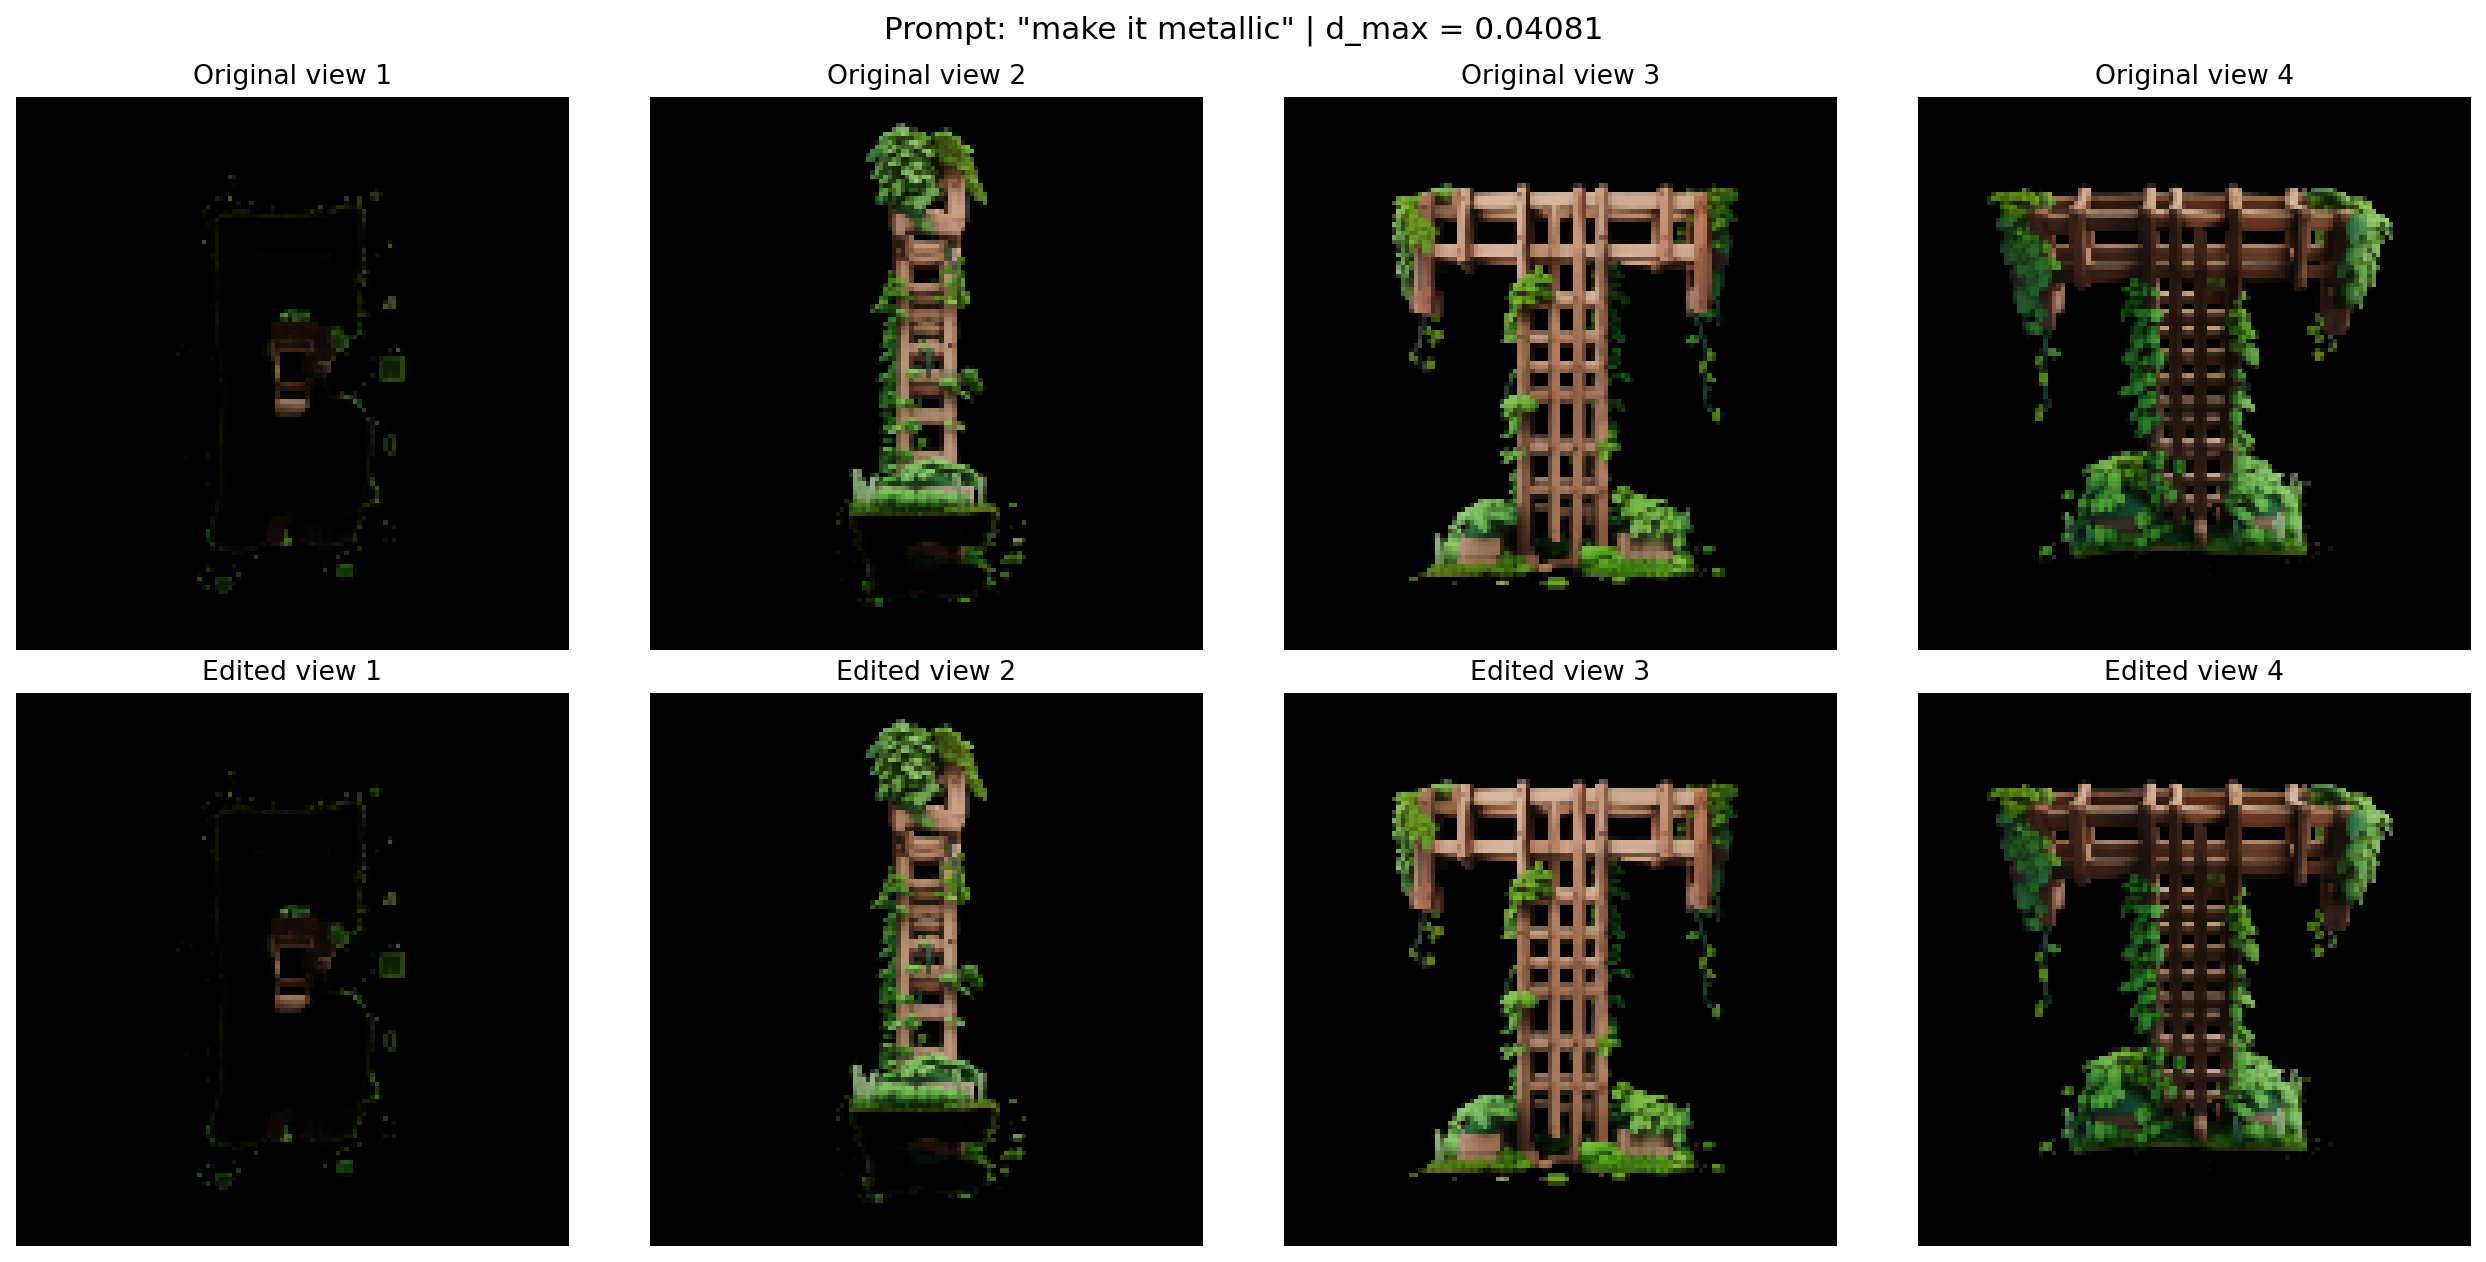

In [33]:
from PIL import Image
from IPython.display import display

display(Image.open("/workspace/TRELLIS/artifacts/inference_visual.png"))

## N) Run a medium training configuration

Once the smoke test works, I move to a medium run.  
This is my next stable scaling step before trying anything much larger.

I keep the render resolution at `128` and the voxel cap active to keep the run manageable.

In [ ]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

cd /workspace/TRELLIS
unset HF_HUB_OFFLINE

export EDIT_EPOCHS=10
export EDIT_MAX_OBJECTS=20
export EDIT_PROMPTS_PER_OBJECT=3
export EDIT_N_VIEWS=1
export EDIT_RENDER_RES=128
export EDIT_TEXT_GAIN=4.0
export EDIT_TEXT_REPEAT=8
export EDIT_SCALE=0.15
export EDIT_LAMBDA_DELTA=0.02
export EDIT_LAMBDA_PRESERVE=0.05
export EDIT_MAX_VOXELS=22000
export EDIT_CACHE_DIR=/workspace/edit_training_data/encoded_latents
export EDIT_PAIRS_JSON=/workspace/edit_training_data/training_pairs.json
export EDIT_CKPT_DIR=/workspace/edit_checkpoints
export EDIT_LOG=/workspace/TRELLIS/artifacts/run_medium.log

/content/miniconda/envs/trellis/bin/python -u /workspace/TRELLIS/train_edit_delta_scalable.py 2>&1 | tee "$EDIT_LOG"

## O) Inspect the medium run

In this cell I inspect the medium-run training log and the saved checkpoints.

In [ ]:
%%bash
echo "===== LOG TAIL ====="
tail -n 120 /workspace/TRELLIS/artifacts/run_medium.log || true

echo
echo "===== CHECKPOINTS ====="
ls -lh /workspace/edit_checkpoints || true

## P) Run a larger training configuration for a stronger GPU

This is the larger configuration I would use on a stronger Colab Pro / higher-memory GPU.

Important note:
- I should only run this after the smoke test and the medium run both work.
- If the runtime has enough VRAM, I can increase object count, prompt count, and number of rendered views here.

In [ ]:
%%bash
set -eo pipefail
source /content/trellis_env.sh

cd /workspace/TRELLIS
unset HF_HUB_OFFLINE

export EDIT_EPOCHS=20
export EDIT_MAX_OBJECTS=100
export EDIT_PROMPTS_PER_OBJECT=5
export EDIT_N_VIEWS=2
export EDIT_RENDER_RES=128
export EDIT_TEXT_GAIN=4.0
export EDIT_TEXT_REPEAT=8
export EDIT_SCALE=0.15
export EDIT_LAMBDA_DELTA=0.02
export EDIT_LAMBDA_PRESERVE=0.05
export EDIT_MAX_VOXELS=22000
export EDIT_CACHE_DIR=/workspace/edit_training_data/encoded_latents
export EDIT_PAIRS_JSON=/workspace/edit_training_data/training_pairs.json
export EDIT_CKPT_DIR=/workspace/edit_checkpoints
export EDIT_LOG=/workspace/TRELLIS/artifacts/run_large.log

/content/miniconda/envs/trellis/bin/python -u /workspace/TRELLIS/train_edit_delta_scalable.py 2>&1 | tee "$EDIT_LOG"